In [25]:
import pandas as pd
df = pd.read_excel('Online Retail.xlsx')
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [4]:
df.dropna(subset=['CustomerID'], inplace=True)

df = df[df['Quantity'] > 0].copy()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['CustomerID'] = df['CustomerID'].astype(int)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  int64         
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.3+ MB
None


In [5]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print(df.head(5))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  


In [6]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Tanggal Snapshot: {snapshot_date}")

rfm_data = df.groupby(['CustomerID']).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, #recency- selisih hari dari transaksi terakhir
    'InvoiceNo': 'nunique',                                  #frequency- jumlah invoice unik (transaksi)
    'TotalPrice': 'sum'                                      #monetary- total uang yang dibelanjakan
})

rfm_data.rename(columns={'InvoiceDate': 'Recency',
                         'InvoiceNo': 'Frequency',
                         'TotalPrice': 'MonetaryValue'}, inplace=True)

print(rfm_data.head())

Tanggal Snapshot: 2011-12-10 12:50:00
            Recency  Frequency  MonetaryValue
CustomerID                                   
12346           326          1       77183.60
12347             2          7        4310.00
12348            75          4        1797.24
12349            19          1        1757.55
12350           310          1         334.40


In [10]:
r_labels = range(5, 0, -1)
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], q=5, labels=r_labels, duplicates='drop').astype(int)

fm_labels = range(1, 6)

rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), q=5, labels=fm_labels).astype(int)

rfm_data['M_Score'] = pd.qcut(rfm_data['MonetaryValue'].rank(method='first'), q=5, labels=fm_labels).astype(int)
print("Tabel RFM dengan Skor:")
print(rfm_data.head())

Tabel RFM dengan Skor:
            Recency  Frequency  MonetaryValue  R_Score  F_Score  M_Score
CustomerID                                                              
12346           326          1       77183.60        1        1        5
12347             2          7        4310.00        5        5        5
12348            75          4        1797.24        2        4        4
12349            19          1        1757.55        4        1        4
12350           310          1         334.40        1        1        2


In [15]:
def join_rfm(x):
  return str(x['R_Score']) + str(x['F_Score']) + str(x['M_Score'])

rfm_data['RFM_Segment'] = rfm_data.apply(join_rfm, axis=1)

rfm_data['RFM_Score'] = rfm_data[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

print(rfm_data.head())

            Recency  Frequency  MonetaryValue  R_Score  F_Score  M_Score  \
CustomerID                                                                 
12346           326          1       77183.60        1        1        5   
12347             2          7        4310.00        5        5        5   
12348            75          4        1797.24        2        4        4   
12349            19          1        1757.55        4        1        4   
12350           310          1         334.40        1        1        2   

           RFM_Segment  RFM_Score  
CustomerID                         
12346              115          7  
12347              555         15  
12348              244         10  
12349              414          9  
12350              112          4  


In [16]:
segment_map = {
    r'[1-2][1-2]': 'Hibernating',        # Skor R dan F rendah -> Hampir hilang
    r'[1-2][3-4]': 'At-Risk',            # Jarang kembali, tapi dulu sering/nilai tinggi
    r'[1-2]5': 'Cannot Lose Them',       # Dulu pelanggan terbaik, sekarang jarang kembali
    r'3[1-2]': 'About to Sleep',         # Rata-rata, tapi frekuensi rendah
    r'33': 'Needs Attention',            # Rata-rata di semua metrik
    r'[3-4][4-5]': 'Loyal Customers',    # Sering membeli & nilai transaksi tinggi
    r'[4-5]1': 'New Customers',          # Baru saja membeli, tapi baru sekali
    r'[4-5][2-5]': 'Potential Loyalists & Champions' # Gabungan pelanggan potensial & juara
}

In [18]:
rfm_data['Segment'] = rfm_data['R_Score'].astype(str) + rfm_data['F_Score'].astype(str)
rfm_data['Segment'] = rfm_data['Segment'].replace(segment_map, regex=True)

print("Tabel RFM dengan Nama Segmen:")
print(rfm_data.head())

Tabel RFM dengan Nama Segmen:
            Recency  Frequency  MonetaryValue  R_Score  F_Score  M_Score  \
CustomerID                                                                 
12346           326          1       77183.60        1        1        5   
12347             2          7        4310.00        5        5        5   
12348            75          4        1797.24        2        4        4   
12349            19          1        1757.55        4        1        4   
12350           310          1         334.40        1        1        2   

           RFM_Segment  RFM_Score                          Segment  
CustomerID                                                          
12346              115          7                      Hibernating  
12347              555         15  Potential Loyalists & Champions  
12348              244         10                          At-Risk  
12349              414          9                    New Customers  
12350              112 

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
segment_counts = rfm_data['Segment'].value_counts().sort_values(ascending=False)

/tmp/ipython-input-21-3372890089.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')


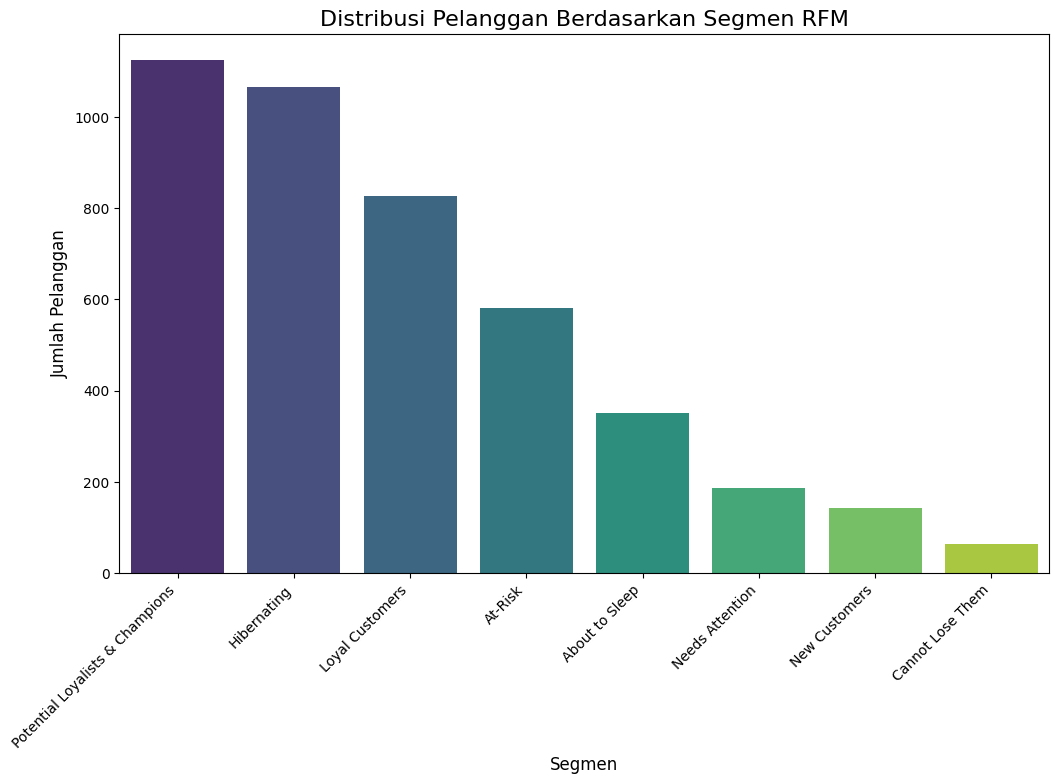

In [21]:
plt.figure(figsize=(12, 7))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Distribusi Pelanggan Berdasarkan Segmen RFM', fontsize=16)
plt.xlabel('Segmen', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.xticks(rotation=45, ha='right') # Memutar label agar tidak tumpang tindih
plt.show()

In [23]:
rfm_data.to_csv('rfm_analysis_for_dashboard.csv')

print("\nAnalisis selesai!")
print("File 'rfm_analysis_for_dashboard.csv' telah disimpan dan siap digunakan untuk membuat dashboard.")


Analisis selesai!
File 'rfm_analysis_for_dashboard.csv' telah disimpan dan siap digunakan untuk membuat dashboard.


In [24]:
rfm_data.head()

,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
CustomerID,,,,,,,,,
12346,326,1,77183.60,1,1,5,115,7,Hibernating
12347,2,7,4310.00,5,5,5,555,15,Potential Loyalists & Champions
12348,75,4,1797.24,2,4,4,244,10,At-Risk
12349,19,1,1757.55,4,1,4,414,9,New Customers
12350,310,1,334.40,1,1,2,112,4,Hibernating
